In [1]:
import cv2
import numpy as np
from IPython.display import Image, display
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt

In [2]:
def preprocess_image(image_path, close_size=10, open_size=20):
    """
    Preprocesamiento de la imagen según el paper:
    1. Operación closing con disco de 10px
    2. Operación opening con disco de 20px
    3. Reconstrucción morfológica
    4. Umbralización adaptativa
    5. Rellenado de agujeros
    6. Ajuste del disco solar a círculo perfecto
    """
    # Leer imagen original
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    original = img.copy()
    
    # 1. Closing con disco de 10px
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_size, close_size))
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_close)
    
    # 2. Opening con disco de 20px
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_size, open_size))
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)
    
    # 3. Reconstrucción morfológica
    # Marker: imagen opened - original
    marker = cv2.subtract(opened, original)
    # Máscara: imagen original
    mask = original
    
    # Reconstrucción por dilatación
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    while True:
        marker_new = cv2.dilate(marker, kernel)
        marker_new = cv2.min(marker_new, mask)
        if np.array_equal(marker, marker_new):
            break
        marker = marker_new
    
    # 4. Umbralización adaptativa (30-124 como en el paper)
    _, thresh = cv2.threshold(marker, 30, 255, cv2.THRESH_BINARY)
    
    # 5. Rellenar agujeros
    filled = thresh.copy()
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)
    
    # 6. Ajustar disco solar a círculo perfecto
    # Encontrar centro y radio del disco solar
    (x, y), radius = find_solar_disk(filled)
    
    # Crear máscara circular perfecta
    circle_mask = np.zeros_like(filled)
    cv2.circle(circle_mask, (x, y), radius, 255, -1)
    
    # Multiplicar con la imagen original para obtener resultado final
    final = cv2.bitwise_and(original, original, mask=circle_mask)
    
    return final, (x, y, radius)


In [3]:
def find_solar_disk(binary_img):
    """
    Encuentra el centro y radio del disco solar en una imagen binaria
    Basado en el método descrito en la sección 4.1 del paper
    """
    # Encontrar contornos
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return (0, 0), 0
    
    # Tomar el contorno más grande (disco solar)
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Encontrar círculo mínimo que engloba el contorno
    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
    
    return (int(x), int(y)), int(radius)


In [4]:
def detect_sunspots_morphology(preprocessed_img):
    """
    Detección de manchas solares usando morfología matemática:
    1. Black top-hat transform con disco de 20px
    2. Umbralización adaptativa (20-255)
    3. Erosión y reconstrucción
    4. Gradiente morfológico y adelgazamiento
    """
    # 1. Black top-hat transform
    kernel_size = 20
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(preprocessed_img, cv2.MORPH_BLACKHAT, kernel)
    
    # 2. Umbralización adaptativa (20-255)
    _, thresh = cv2.threshold(blackhat, 20, 255, cv2.THRESH_BINARY)
    
    # 3. Erosión (disco de 1px) y reconstrucción
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, 1))
    eroded = cv2.erode(thresh, kernel_erode)
    
    # Reconstrucción
    reconstructed = thresh.copy()
    kernel_recon = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    while True:
        reconstructed_new = cv2.dilate(reconstructed, kernel_recon)
        reconstructed_new = cv2.min(reconstructed_new, thresh)
        if np.array_equal(reconstructed, reconstructed_new):
            break
        reconstructed = reconstructed_new
    
    # 4. Gradiente morfológico y adelgazamiento
    gradient = cv2.morphologyEx(reconstructed, cv2.MORPH_GRADIENT, kernel_recon)
    
    # Adelgazamiento (thinning)
    #thinned = cv2.ximgproc.thinning(gradient)
    thinned = gradient.copy()  # O simplemente omite el adelgazamiento
    
    return thinned, reconstructed


In [5]:
def segment_umbra_penumbra(sunspots_mask, original_img):
    """
    Segmentación de umbra y penumbra basada en histogramas de niveles de gris
    """
    # Etiquetar cada mancha solar
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(sunspots_mask, 8, cv2.CV_32S)
    
    umbra_mask = np.zeros_like(sunspots_mask)
    penumbra_mask = np.zeros_like(sunspots_mask)
    
    for label in range(1, num_labels):
        # Aislar la mancha solar actual
        spot_mask = (labels == label).astype(np.uint8) * 255
        spot_pixels = cv2.bitwise_and(original_img, original_img, mask=spot_mask)
        
        # Calcular min y max de niveles de gris
        min_val = np.min(spot_pixels[spot_pixels > 0])
        max_val = np.max(spot_pixels[spot_pixels > 0])
        
        # Determinar si es bimodal (umbra+penumbra) o unimodal (solo umbra)
        if (max_val - min_val) > 20:  # Bimodal según el paper
            # Umbral para separar umbra y penumbra (ecuación 1 del paper)
            threshold = (max_val - min_val) / 2 + min_val
            
            # Segmentar umbra (valores más oscuros)
            _, umbra = cv2.threshold(spot_pixels, threshold - 1, 255, cv2.THRESH_BINARY_INV)
            umbra = cv2.bitwise_and(umbra, umbra, mask=spot_mask)
            
            # Segmentar penumbra (valores más claros)
            _, penumbra = cv2.threshold(spot_pixels, threshold, 255, cv2.THRESH_BINARY)
            penumbra = cv2.bitwise_and(penumbra, penumbra, mask=spot_mask)
        else:  # Unimodal - solo umbra
            umbra = spot_mask.copy()
            penumbra = np.zeros_like(spot_mask)
        
        # Agregar a las máscaras finales
        umbra_mask = cv2.bitwise_or(umbra_mask, umbra)
        penumbra_mask = cv2.bitwise_or(penumbra_mask, penumbra)
    
    return umbra_mask, penumbra_mask


In [6]:
def mask_to_bboxes(mask, min_area=None, max_area=None, border_margin=5):
    """
    Convierte una máscara binaria en una lista de bounding boxes [x_min, y_min, x_max, y_max].
    Descarta bboxes que tocan los bordes de la imagen (con margen).
    """
    height, width = mask.shape
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        # Filtrar por área
        if ((min_area is None) or (area >= min_area)) and ((max_area is None) or (area <= max_area)):
            # Filtrar por posición: descartar si toca los bordes (con margen)
            if (x <= border_margin or y <= border_margin or
                x + w >= width - border_margin or y + h >= height - border_margin):
                continue  # descarta bbox en el borde
            bboxes.append([x, y, x + w, y + h])
    return bboxes

In [7]:
def draw_bboxes(image, bboxes, color=(255,0,0), thickness=2):
    # Si la imagen es de un solo canal, conviértela a BGR
    if len(image.shape) == 2:
        img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        img = image.copy()
    for bbox in bboxes:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img



In [8]:
def visualize_results(original_img, preprocessed_img, sunspots, umbra, penumbra):
    """Visualización de los resultados intermedios y finales"""
    
    # Visualizar imagen original
    print("original")
    display(PILImage.fromarray(original_img))

    # Visualizar imagen preprocesada
    print("preprocesada")
    display(PILImage.fromarray(preprocessed_img))

    # Visualizar detección de manchas solares (sunspots)
    print("detección de manchas solares")
    sunspots_overlay = PILImage.fromarray(original_img).convert("RGBA")
    mask_img = PILImage.fromarray(sunspots).convert("L").resize(sunspots_overlay.size)
    color_mask = PILImage.new("RGBA", sunspots_overlay.size, (255, 0, 0, 100))
    sunspots_overlay.paste(color_mask, (0, 0), mask_img)
    display(sunspots_overlay)

    # Visualizar umbra
    print("umbra")
    umbra_overlay = PILImage.fromarray(original_img).convert("RGBA")
    umbra_mask_img = PILImage.fromarray(umbra).convert("L").resize(umbra_overlay.size)
    color_umbra = PILImage.new("RGBA", umbra_overlay.size, (255, 0, 0, 100))
    umbra_overlay.paste(color_umbra, (0, 0), umbra_mask_img)
    display(umbra_overlay)

    # Visualizar penumbra
    print("penumbra")
    penumbra_overlay = PILImage.fromarray(original_img).convert("RGBA")
    penumbra_mask_img = PILImage.fromarray(penumbra).convert("L").resize(penumbra_overlay.size)
    color_penumbra = PILImage.new("RGBA", penumbra_overlay.size, (0, 0, 255, 100))
    penumbra_overlay.paste(color_penumbra, (0, 0), penumbra_mask_img)
    display(penumbra_overlay)

    # Visualizar combinación umbra y penumbra
    print("combinación umbra y penumbra")
    combined_overlay = PILImage.fromarray(original_img).convert("RGBA")
    combined_overlay.paste(color_umbra, (0, 0), umbra_mask_img)
    combined_overlay.paste(color_penumbra, (0, 0), penumbra_mask_img)
    display(combined_overlay)


original


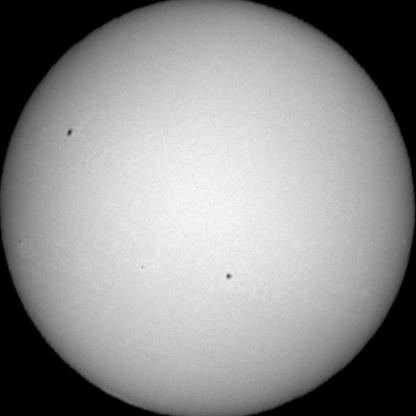

preprocesada


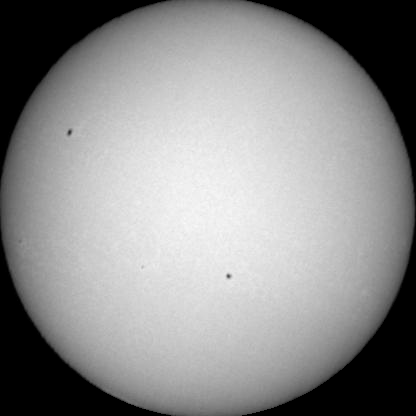

detección de manchas solares


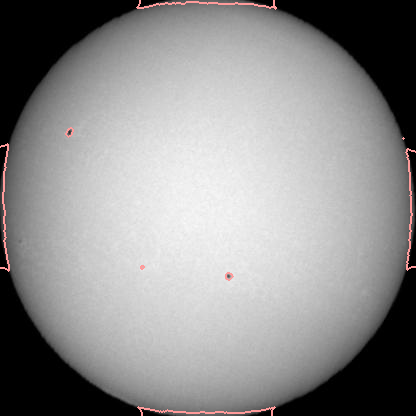

umbra


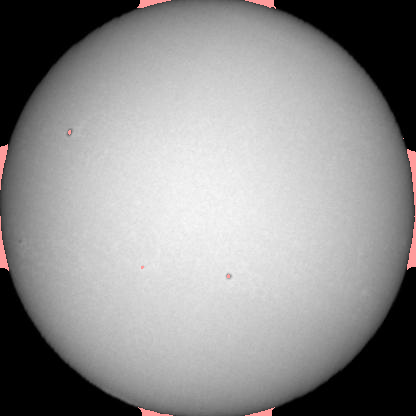

penumbra


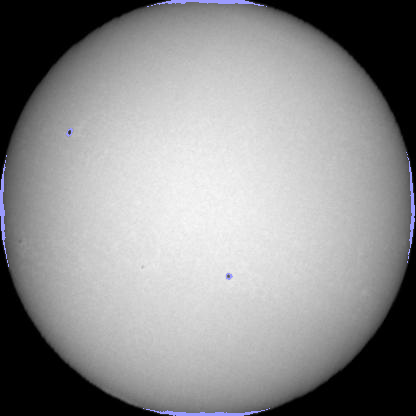

combinación umbra y penumbra


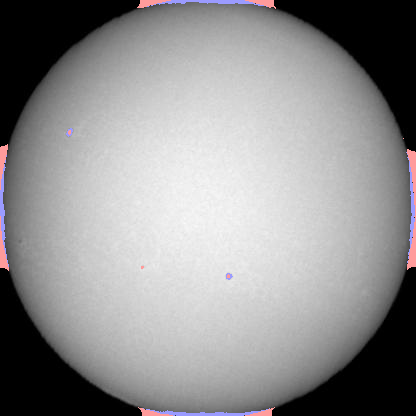

sunspot con filtro de área


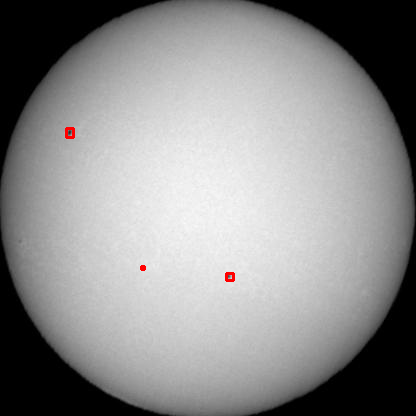

In [9]:
# Cargar imagen (reemplazar con tu ruta)
image_path = "dataset/OGAUC/train/images/14042507CN_jpg.rf.3fb2526edeac9c97310b2f71145f0d30.jpg"
labels_path = "dataset/OGAUC/train/labels/14042507CN_jpg.rf.3fb2526edeac9c97310b2f71145f0d30.txt"
# 1. Preprocesamiento
preprocessed, (x, y, radius) = preprocess_image(image_path)

# 2. Detección de manchas solares
sunspots_contours, sunspots_mask = detect_sunspots_morphology(preprocessed)

# 3. Segmentación umbra/penumbra
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
umbra, penumbra = segment_umbra_penumbra(sunspots_mask, original_img)


# Visualización
visualize_results(original_img, preprocessed, sunspots_contours, umbra, penumbra)

print("sunspot con filtro de área")
bboxes = mask_to_bboxes(sunspots_mask,min_area=2)
img_with_bboxes = draw_bboxes(original_img, bboxes)
display(PILImage.fromarray(img_with_bboxes))
#plt.imshow(cv2.cvtColor(img_with_bboxes, cv2.COLOR_BGR2RGB))
#plt.show()

In [10]:
def load_yolo_labels(label_file, img_shape):
    bboxes = []
    h, w = img_shape
    with open(label_file, 'r') as f:
        for line in f:
            _, x, y, bw, bh = map(float, line.strip().split())
            x_min = int((x - bw/2) * w)
            y_min = int((y - bh/2) * h)
            x_max = int((x + bw/2) * w)
            y_max = int((y + bh/2) * h)
            bboxes.append([x_min, y_min, x_max, y_max])
    return bboxes

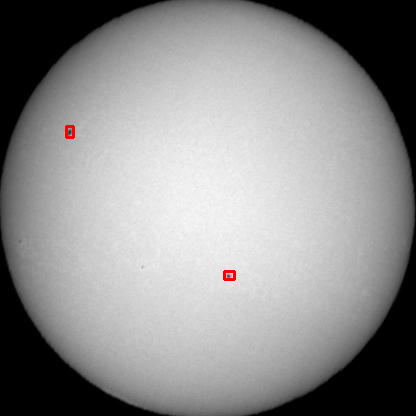

In [12]:
label_bbox = load_yolo_labels(labels_path, original_img.shape[:2])
img_with_bboxes = draw_bboxes(original_img, label_bbox)
display(PILImage.fromarray(img_with_bboxes))